In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/final_reviwes.csv")
df.head()

,ratings,reviews
0,5,Overall a good clubbing experience
1,5,Mr. Rajendra Singh Chauhan had provided excell...
2,5,Service was really was really good by vimal sa...
3,5,Awsme food and service...Mohit chaudhary good ...
4,5,This spot gives extraordinary service and yumm...


- remove punctuations
- lower casing
- handle emoji
- remove mobile number but not numbers
- remove hindi reviews
- remove stop words
- stemming/lemmatization

In [3]:
df.sample(15)

,ratings,reviews
24432,5,NaN
37895,5,Paneer lababdar was awesome and the man name s...
8911,5,amazing place with great view of whole pink Ci...
8959,5,Kudos to team for delivering Special White F...
5241,5,Good taste good taste
11607,5,Maska bun chai and poha just amazing and tasty
39621,5,............. Very good place. Good for party....
25021,5,The Dal Bukhara here is too good! I couldn't r...
28636,5,Great ambience with such an amazing staff ..fi...
21505,5,NaN


In [4]:
df.shape

(47665, 2)

In [5]:
df.isnull().sum()

ratings        0
reviews    13293
dtype: int64

In [6]:
df.dropna(inplace = True)

In [7]:
df

,ratings,reviews
0,5,Overall a good clubbing experience
1,5,Mr. Rajendra Singh Chauhan had provided excell...
2,5,Service was really was really good by vimal sa...
3,5,Awsme food and service...Mohit chaudhary good ...
4,5,This spot gives extraordinary service and yumm...
...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...
47639,5,The dal was amazing. Just the perfect blend of...
47643,1,"this dal bati churma no test and high rates, c..."
47644,4,It was a nice Rajasthani Thali but batti was n...


In [8]:
df["sentiment"] = np.where(df["ratings"] >= 4,0,1)
df

,ratings,reviews,sentiment
0,5,Overall a good clubbing experience,0
1,5,Mr. Rajendra Singh Chauhan had provided excell...,0
2,5,Service was really was really good by vimal sa...,0
3,5,Awsme food and service...Mohit chaudhary good ...,0
4,5,This spot gives extraordinary service and yumm...,0
...,...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...,1
47639,5,The dal was amazing. Just the perfect blend of...,0
47643,1,"this dal bati churma no test and high rates, c...",1
47644,4,It was a nice Rajasthani Thali but batti was n...,0


In [9]:
df["sentiment"].value_counts(1)

sentiment
0    0.746276
1    0.253724
Name: proportion, dtype: float64

## remove puctuations

In [10]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [11]:
a = "food! is/ good."
a

'food! is/ good.'

In [12]:
a = a.replace("!","")
a

'food is/ good.'

In [13]:
b = "".join([" " if i in string.punctuation else i for i in a])
b

'food is  good '

In [14]:
b

'food is  good '

In [15]:
b.replace(" +", "")

'food is  good '

In [16]:
b.split()

['food', 'is', 'good']

In [17]:
" ".join(b.split())

'food is good'

In [18]:
import regex as re
re.sub(r"\s\s+", " ", b)
# b.replace(r"\s\s+"," ")

'food is good '

In [19]:
def rem_punc(text):
  a = "".join([" " if i in string.punctuation else i for i in text])
  # a = re.sub(r"\s\s+", " ", a)
  # a = a.strip()
  a = " ".join(a.split())
  return a

In [20]:
df["no_punc"] = df["reviews"].apply(lambda x: rem_punc(x))
df

,ratings,reviews,sentiment,no_punc
0,5,Overall a good clubbing experience,0,Overall a good clubbing experience
1,5,Mr. Rajendra Singh Chauhan had provided excell...,0,Mr Rajendra Singh Chauhan had provided excelle...
2,5,Service was really was really good by vimal sa...,0,Service was really was really good by vimal sa...
3,5,Awsme food and service...Mohit chaudhary good ...,0,Awsme food and service Mohit chaudhary good pe...
4,5,This spot gives extraordinary service and yumm...,0,This spot gives extraordinary service and yumm...
...,...,...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...,1,bati was Completely burnt 🥵 most pathetic dal ...
47639,5,The dal was amazing. Just the perfect blend of...,0,The dal was amazing Just the perfect blend of ...
47643,1,"this dal bati churma no test and high rates, c...",1,this dal bati churma no test and high rates ch...
47644,4,It was a nice Rajasthani Thali but batti was n...,0,It was a nice Rajasthani Thali but batti was n...


In [21]:
df.sample(10)

,ratings,reviews,sentiment,no_punc
30652,5,The place was good and the waiter Soaib was ve...,0,The place was good and the waiter Soaib was ve...
40748,1,Better than this i would have brought food for...,1,Better than this i would have brought food for...
36484,5,A hub of young professionals at work amidst a ...,0,A hub of young professionals at work amidst a ...
1138,5,Udon noodles was really good and water melon i...,0,Udon noodles was really good and water melon i...
42793,4,Loved the place!Grand entrance as the name sta...,0,Loved the place Grand entrance as the name sta...
4327,5,The taste of the food was very good. Paneer ti...,0,The taste of the food was very good Paneer tik...
9048,5,Basbousa Cake was a pleasant surprise! It rea...,0,Basbousa Cake was a pleasant surprise It reach...
3669,5,awesome place to visit Amar Singh service and ...,0,awesome place to visit Amar Singh service and ...
8365,5,All in one place for family and friends qualit...,0,All in one place for family and friends qualit...
33254,1,The white sause pasta was so horiblee it felt ...,1,The white sause pasta was so horiblee it felt ...


## lower caseing

In [22]:
df["lower"] = df["no_punc"].str.lower()

## Handle emoji
1. remove them
2. replace emoji with text

In [23]:
! pip install emoji

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.4/431.4 kB 9.1 MB/s eta 0:00:00


In [24]:
import emoji
a = "i am happy 😁"
b = "bati was Completely burnt 🥵. most pathetic dal"
emoji.demojize(b)

'bati was Completely burnt :hot_face:. most pathetic dal'

In [25]:
def demoji(text):
  return emoji.demojize(text)

df["demoji"] = df["lower"].apply(lambda x: demoji(x))
df

,ratings,reviews,sentiment,no_punc,lower,demoji
0,5,Overall a good clubbing experience,0,Overall a good clubbing experience,overall a good clubbing experience,overall a good clubbing experience
1,5,Mr. Rajendra Singh Chauhan had provided excell...,0,Mr Rajendra Singh Chauhan had provided excelle...,mr rajendra singh chauhan had provided excelle...,mr rajendra singh chauhan had provided excelle...
2,5,Service was really was really good by vimal sa...,0,Service was really was really good by vimal sa...,service was really was really good by vimal sa...,service was really was really good by vimal sa...
3,5,Awsme food and service...Mohit chaudhary good ...,0,Awsme food and service Mohit chaudhary good pe...,awsme food and service mohit chaudhary good pe...,awsme food and service mohit chaudhary good pe...
4,5,This spot gives extraordinary service and yumm...,0,This spot gives extraordinary service and yumm...,this spot gives extraordinary service and yumm...,this spot gives extraordinary service and yumm...
...,...,...,...,...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...,1,bati was Completely burnt 🥵 most pathetic dal ...,bati was completely burnt 🥵 most pathetic dal ...,bati was completely burnt :hot_face: most path...
47639,5,The dal was amazing. Just the perfect blend of...,0,The dal was amazing Just the perfect blend of ...,the dal was amazing just the perfect blend of ...,the dal was amazing just the perfect blend of ...
47643,1,"this dal bati churma no test and high rates, c...",1,this dal bati churma no test and high rates ch...,this dal bati churma no test and high rates ch...,this dal bati churma no test and high rates ch...
47644,4,It was a nice Rajasthani Thali but batti was n...,0,It was a nice Rajasthani Thali but batti was n...,it was a nice rajasthani thali but batti was n...,it was a nice rajasthani thali but batti was n...


In [26]:
a = '''this place is good - https://developer.mozilla.org/en-US/docs/Web/JavaScript/Guide/Regular_expressions/Cheatsheet
contact on this no.- 8875654562. Price of coffee is 170'''
a


'this place is good - https://developer.mozilla.org/en-US/docs/Web/JavaScript/Guide/Regular_expressions/Cheatsheet\ncontact on this no.- 8875654562. Price of coffee is 170'

In [27]:
mobile_regex = "(\+*)((0[ -]*)*|((91 )*))((\d{12})+|(\d{10})+)|\d{5}([- ]*)\d{6}"
url_regex = "((http|https|www)\:\/\/)?[a-zA-Z0-9\.\/\?\:@\-_=#]+\.([a-zA-Z]){2,6}([a-zA-Z0-9\.\&\/\?\:@\-_=#])*"
a = re.sub(mobile_regex," ", a)
a = re.sub(url_regex," ", a)
a

'this place is good -  \ncontact on this no.-  . Price of coffee is 170'

In [28]:
def text_cleaner(text):
  mobile_regex = "(\+*)((0[ -]*)*|((91 )*))((\d{12})+|(\d{10})+)|\d{5}([- ]*)\d{6}"
  url_regex = "((http|https|www)\:\/\/)?[a-zA-Z0-9\.\/\?\:@\-_=#]+\.([a-zA-Z]){2,6}([a-zA-Z0-9\.\&\/\?\:@\-_=#])*"

  #punctuation
  a = "".join([" " if i in string.punctuation else i for i in text])
  # lower case
  a = a.lower()
  # demoji
  a = emoji.demojize(a)
  # remove mobile
  a = re.sub(mobile_regex," ", a)
  # remove url
  a = re.sub(url_regex," ", a)



  a = " ".join(a.split())
  return a

In [29]:
df["tc1"] = df["reviews"].apply(lambda x: text_cleaner(x))
df = df[["sentiment", "reviews", "tc1"]]
df

,sentiment,reviews,tc1
0,0,Overall a good clubbing experience,overall a good clubbing experience
1,0,Mr. Rajendra Singh Chauhan had provided excell...,mr rajendra singh chauhan had provided excelle...
2,0,Service was really was really good by vimal sa...,service was really was really good by vimal sa...
3,0,Awsme food and service...Mohit chaudhary good ...,awsme food and service mohit chaudhary good pe...
4,0,This spot gives extraordinary service and yumm...,this spot gives extraordinary service and yumm...
...,...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...,bati was completely burnt :hot_face: most path...
47639,0,The dal was amazing. Just the perfect blend of...,the dal was amazing just the perfect blend of ...
47643,1,"this dal bati churma no test and high rates, c...",this dal bati churma no test and high rates ch...
47644,0,It was a nice Rajasthani Thali but batti was n...,it was a nice rajasthani thali but batti was n...


In [30]:
# find hindi reviews using regex
a = re.sub("[^\u0900-\u097F]+"," ", a)

In [31]:
a = "his dal bati churma no test and hi आज का मौसम ाचा है "

In [32]:
re.findall(r"[\u0900-\u097F]+", a)

['आज', 'का', 'मौसम', 'ाचा', 'है']

In [33]:
hindi_regex = "[\u0904-\u0939\u093E-\u094D\u0950-\u0954\u0958-\u0963\u0966-\u096F]+"

In [34]:
mask = df["tc1"].apply(lambda x: True if len(re.findall(hindi_regex, x)) > 0 else False)
df[mask].shape

(54, 3)

In [35]:
df.shape

(34372, 3)

In [36]:
df.drop(index = df[mask].index, inplace=True)

<ipython-input-36-88dba1b09948>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(index = df[mask].index, inplace=True)


## remove stopwords

In [37]:
df.sample(5)

,sentiment,reviews,tc1
18502,0,both food and ambience were good,both food and ambience were good
23984,0,Amazing food experience with delicious taste.....,amazing food experience with delicious taste a...
30820,0,I'm visited most of the clubs but this playboy...,i m visited most of the clubs but this playboy...
18865,0,excellent food excellent sarvice nirmal ji,excellent food excellent sarvice nirmal ji
4003,1,I am regular coustmor of them Online Aur offli...,i am regular coustmor of them online aur offli...


In [38]:
! pip install nltk

In [39]:
import nltk
nltk.download('popular')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

True

In [40]:
imp_word = ['but','against','no',
 'nor',
 'not','don',
 "don't",'ain',
 'aren',
 "aren't",
 'couldn',
 "couldn't",
 'didn',
 "didn't",
 'doesn',
 "doesn't",
 'hadn',
 "hadn't",
 'hasn',
 "hasn't",
 'haven',
 "haven't",
 'isn',
 "isn't",
 'ma',
 'mightn',
 "mightn't",
 'mustn',
 "mustn't",
 'needn',
 "needn't",
 'shan',
 "shan't",
 'shouldn',
 "shouldn't",
 'wasn',
 "wasn't",
 'weren',
 "weren't",
 'won',
 "won't",
 'wouldn',
 "wouldn't"]

In [41]:
from nltk.corpus import stopwords
sw = stopwords.words("english")
sw

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [42]:
len(sw)

179

In [43]:
len(imp_word)

43

In [44]:
set([1,3,2,4]) - set([1,4])

{2, 3}

In [45]:
sw = list(set(sw) - set(imp_word))
sw = list(map(lambda x: text_cleaner(x), sw))

In [46]:
df["tc2_sw"] = df["tc1"].apply(lambda x: " ".join([i for i in x.split() if i not in sw]))

<ipython-input-46-cfe74b77fbb9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tc2_sw"] = df["tc1"].apply(lambda x: " ".join([i for i in x.split() if i not in sw]))


In [47]:
df.sample(5)

,sentiment,reviews,tc1,tc2_sw
43806,1,This is a normal onion capsicum tomato pizza. ...,this is a normal onion capsicum tomato pizza n...,normal onion capsicum tomato pizza not laziz p...
4250,1,very bad experience with kebabs $ curries. I w...,very bad experience with kebabs curries i will...,bad experience kebabs curries not buy restaura...
37588,0,Vivek ji hospitality is top notched we had a g...,vivek ji hospitality is top notched we had a g...,vivek ji hospitality top notched great time
38127,1,"I found a piece of clay in the sushi, I liked ...",i found a piece of clay in the sushi i liked t...,found piece clay sushi liked restaurant earlie...
24636,0,Everything is amazing at Kaafila. Amazing serv...,everything is amazing at kaafila amazing servi...,everything amazing kaafila amazing service gre...


## stemming and lemmatization

In [48]:
from nltk.stem import PorterStemmer

In [49]:
ps = PorterStemmer()
a = ["run", "runs", "running", "runner"]
[ps.stem(i) for i in a]

['run', 'run', 'run', 'runner']

In [50]:
wl = nltk.WordNetLemmatizer()
a = ["run", "runs", "running", "runner"]
[wl.lemmatize(i) for i in a]

['run', 'run', 'running', 'runner']

In [51]:
df["tc3_stem"] = df["tc2_sw"].apply(lambda x: " ".join(ps.stem(i) for i in x.split()))
df["tc4_lemma"] = df["tc2_sw"].apply(lambda x: " ".join(wl.lemmatize(i) for i in x.split()))
df

<ipython-input-51-8ee69c05679e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tc3_stem"] = df["tc2_sw"].apply(lambda x: " ".join(ps.stem(i) for i in x.split()))
<ipython-input-51-8ee69c05679e>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["tc4_lemma"] = df["tc2_sw"].apply(lambda x: " ".join(wl.lemmatize(i) for i in x.split()))


,sentiment,reviews,tc1,tc2_sw,tc3_stem,tc4_lemma
0,0,Overall a good clubbing experience,overall a good clubbing experience,overall good clubbing experience,overal good club experi,overall good clubbing experience
1,0,Mr. Rajendra Singh Chauhan had provided excell...,mr rajendra singh chauhan had provided excelle...,mr rajendra singh chauhan provided excellent s...,mr rajendra singh chauhan provid excel servic ...,mr rajendra singh chauhan provided excellent s...
2,0,Service was really was really good by vimal sa...,service was really was really good by vimal sa...,service really really good vimal sagar food re...,servic realli realli good vimal sagar food rea...,service really really good vimal sagar food re...
3,0,Awsme food and service...Mohit chaudhary good ...,awsme food and service mohit chaudhary good pe...,awsme food service mohit chaudhary good person,awsm food servic mohit chaudhari good person,awsme food service mohit chaudhary good person
4,0,This spot gives extraordinary service and yumm...,this spot gives extraordinary service and yumm...,spot gives extraordinary service yummy meals o...,spot give extraordinari servic yummi meal one ...,spot give extraordinary service yummy meal one...
...,...,...,...,...,...,...
47636,1,bati was Completely burnt 🥵. most pathetic dal...,bati was completely burnt :hot_face: most path...,bati completely burnt :hot_face: pathetic dal ...,bati complet burnt :hot_face: pathet dal bati ...,bati completely burnt :hot_face: pathetic dal ...
47639,0,The dal was amazing. Just the perfect blend of...,the dal was amazing just the perfect blend of ...,dal amazing perfect blend everything loved lov...,dal amaz perfect blend everyth love love love ...,dal amazing perfect blend everything loved lov...
47643,1,"this dal bati churma no test and high rates, c...",this dal bati churma no test and high rates ch...,dal bati churma no test high rates chilli dal ...,dal bati churma no test high rate chilli dal h...,dal bati churma no test high rate chilli dal h...
47644,0,It was a nice Rajasthani Thali but batti was n...,it was a nice rajasthani thali but batti was n...,nice rajasthani thali but batti not available ...,nice rajasthani thali but batti not avail serv...,nice rajasthani thali but batti not available ...


In [52]:
!pip install wordcloud matplotlib

In [56]:
positive_doc = " ".join(df[df["sentiment"] == 0]["tc4_lemma"])
negative_doc = " ".join(df[df["sentiment"] == 1]["tc4_lemma"])

In [57]:
from wordcloud import WordCloud
wc_positive = WordCloud().generate(positive_doc)
wc_negative = WordCloud().generate(negative_doc)



```
wc = WordCloud(width=800, height=800, background_color='white', max_font_size=50).generate(text)
```



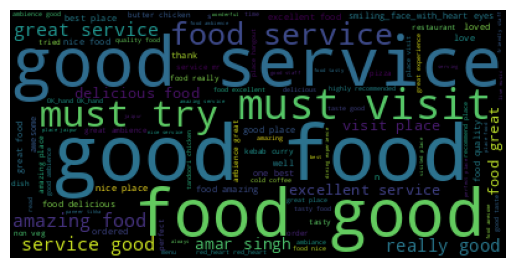

In [60]:
import matplotlib.pyplot as plt
plt.imshow(wc_positive)
plt.axis('off')
plt.show()

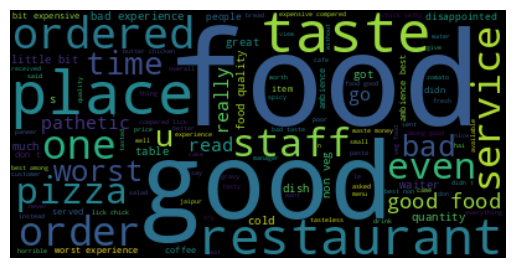

In [59]:
plt.imshow(wc_negative, interpolation='bilinear')
plt.axis('off')
plt.show()